In [3]:
# ==========================================
# Standard Library
# ==========================================
import os
import random
import hashlib
from collections import defaultdict

# ==========================================
# Image Processing
# ==========================================
from PIL import Image
import imagehash

# ==========================================
# Data Handling
# ==========================================
import numpy as np
import pandas as pd

# ==========================================
# Data Visualization
# ==========================================
import matplotlib.pyplot as plt

# ==========================================
# TensorFlow / Keras
# ==========================================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

# ==========================================
# Scikit-learn
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

In [2]:
dataset_path = r"C:\Users\Dell\Documents\intern\plant_disease_detection\PlantVillage-Dataset-master\raw\color"

In [5]:
class_names = sorted(os.listdir(dataset_path))

print("Total Classes:", len(class_names))
print("\nClass Names:")

for cls in class_names:
    print(cls)

Total Classes: 38

Class Names:
Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___Leaf_scorch
Strawberry___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus
T

In [6]:
selected_classes = [
    "Apple___Apple_scab",
    "Apple___Black_rot",
    "Apple___healthy",
    "Corn_(maize)___Common_rust_",
    "Corn_(maize)___healthy",
    "Grape___Black_rot",
    "Grape___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy"
]

In [7]:
for cls in selected_classes:
    if cls in class_names:
        print("✅", cls)
    else:
        print("❌ Not found:", cls)

✅ Apple___Apple_scab
✅ Apple___Black_rot
✅ Apple___healthy
✅ Corn_(maize)___Common_rust_
✅ Corn_(maize)___healthy
✅ Grape___Black_rot
✅ Grape___healthy
✅ Potato___Early_blight
✅ Potato___Late_blight
✅ Potato___healthy


In [8]:
selected_class_counts = {}

for cls in selected_classes:
    class_path = os.path.join(dataset_path, cls)
    selected_class_counts[cls] = len(os.listdir(class_path))

selected_counts_df = pd.DataFrame(
    selected_class_counts.items(),
    columns=["Class", "Image_Count"]
)

print(selected_counts_df)

                         Class  Image_Count
0           Apple___Apple_scab          630
1            Apple___Black_rot          621
2              Apple___healthy         1645
3  Corn_(maize)___Common_rust_         1192
4       Corn_(maize)___healthy         1162
5            Grape___Black_rot         1180
6              Grape___healthy          423
7        Potato___Early_blight         1000
8         Potato___Late_blight         1000
9             Potato___healthy          152


In [9]:
print("Total Images:", selected_counts_df["Image_Count"].sum())

Total Images: 9005


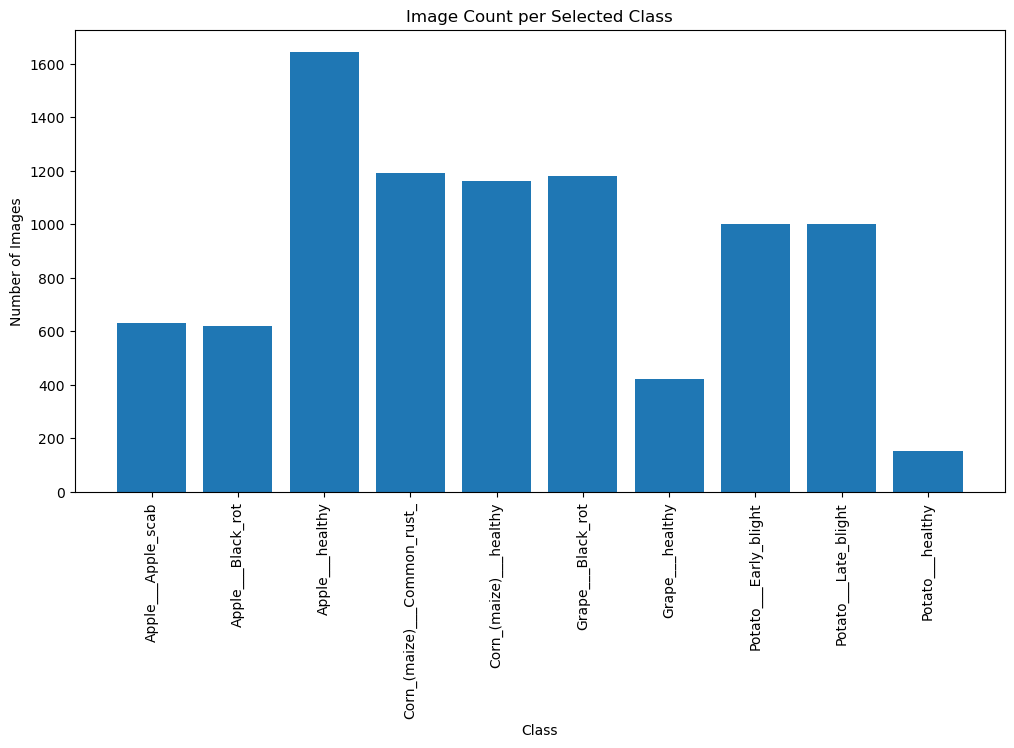

In [10]:
plt.figure(figsize=(12, 6))
plt.bar(selected_counts_df["Class"], selected_counts_df["Image_Count"])
plt.xticks(rotation=90)
plt.title("Image Count per Selected Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

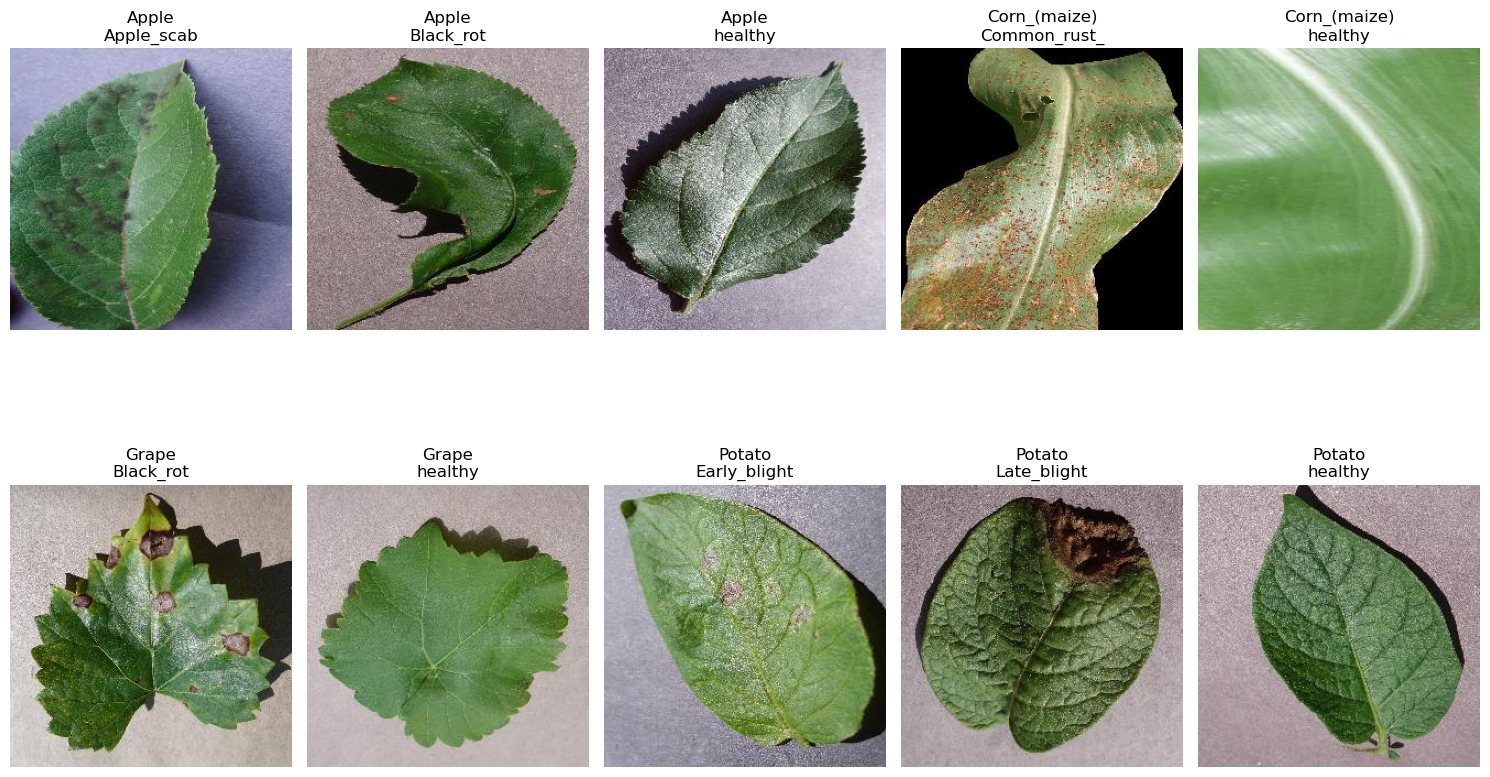

In [ ]:


plt.figure(figsize=(15, 10))

for i, cls in enumerate(selected_classes):
    class_path = os.path.join(dataset_path, cls)
    
    images = os.listdir(class_path)
    random_image = random.choice(images)
    
    image_path = os.path.join(class_path, random_image)
    img = Image.open(image_path)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(cls.replace("___", "\n"))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
image_sizes = []

for cls in selected_classes:
    class_path = os.path.join(dataset_path, cls)

    for file_name in os.listdir(class_path):
        image_path = os.path.join(class_path, file_name)

        try:
            with Image.open(image_path) as img:
                image_sizes.append(img.size)
        except:
            pass

size_df = pd.DataFrame(image_sizes, columns=["Width", "Height"])

print(size_df.head())
print("\nUnique Image Sizes:", size_df.drop_duplicates().shape[0])
print("\nMost Common Sizes:")
print(size_df.value_counts().head(10))

   Width  Height
0    256     256
1    256     256
2    256     256
3    256     256
4    256     256

Unique Image Sizes: 1

Most Common Sizes:
Width  Height
256    256       9005
Name: count, dtype: int64


In [13]:
corrupted_images = []

for cls in selected_classes:
    class_path = os.path.join(dataset_path, cls)

    for file_name in os.listdir(class_path):
        image_path = os.path.join(class_path, file_name)

        try:
            with Image.open(image_path) as img:
                img.verify()
        except Exception:
            corrupted_images.append(image_path)

print("Corrupted Images:", len(corrupted_images))

Corrupted Images: 0


In [14]:
data = []

for cls in selected_classes:
    class_path = os.path.join(dataset_path, cls)

    for file_name in os.listdir(class_path):
        image_path = os.path.join(class_path, file_name)

        data.append([image_path, cls])

df = pd.DataFrame(data, columns=["image_path", "label"])

print(df.head())
print("\nDataset Shape:", df.shape)

                                          image_path               label
0  C:\Users\Dell\Documents\intern\plant_disease_d...  Apple___Apple_scab
1  C:\Users\Dell\Documents\intern\plant_disease_d...  Apple___Apple_scab
2  C:\Users\Dell\Documents\intern\plant_disease_d...  Apple___Apple_scab
3  C:\Users\Dell\Documents\intern\plant_disease_d...  Apple___Apple_scab
4  C:\Users\Dell\Documents\intern\plant_disease_d...  Apple___Apple_scab

Dataset Shape: (9005, 2)


In [16]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

In [17]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

In [18]:
print("Training Images   :", len(train_df))
print("Validation Images :", len(val_df))
print("Testing Images    :", len(test_df))

print("\nTotal:", len(train_df) + len(val_df) + len(test_df))

Training Images   : 6303
Validation Images : 1351
Testing Images    : 1351

Total: 9005


In [20]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 32

In [21]:
class_to_index = {
    class_name: index
    for index, class_name in enumerate(selected_classes)
}

print(class_to_index)

{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___healthy': 2, 'Corn_(maize)___Common_rust_': 3, 'Corn_(maize)___healthy': 4, 'Grape___Black_rot': 5, 'Grape___healthy': 6, 'Potato___Early_blight': 7, 'Potato___Late_blight': 8, 'Potato___healthy': 9}


In [22]:
def preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [23]:
def create_dataset(dataframe, shuffle=False):

    image_paths = dataframe["image_path"].values

    labels = dataframe["label"].map(
        class_to_index
    ).values

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )

    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=42
        )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [24]:
train_ds = create_dataset(train_df, shuffle=True)

val_ds = create_dataset(val_df)

test_ds = create_dataset(test_df)

In [25]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Image batch shape: (32, 256, 256, 3)
Label batch shape: (32,)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [26]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

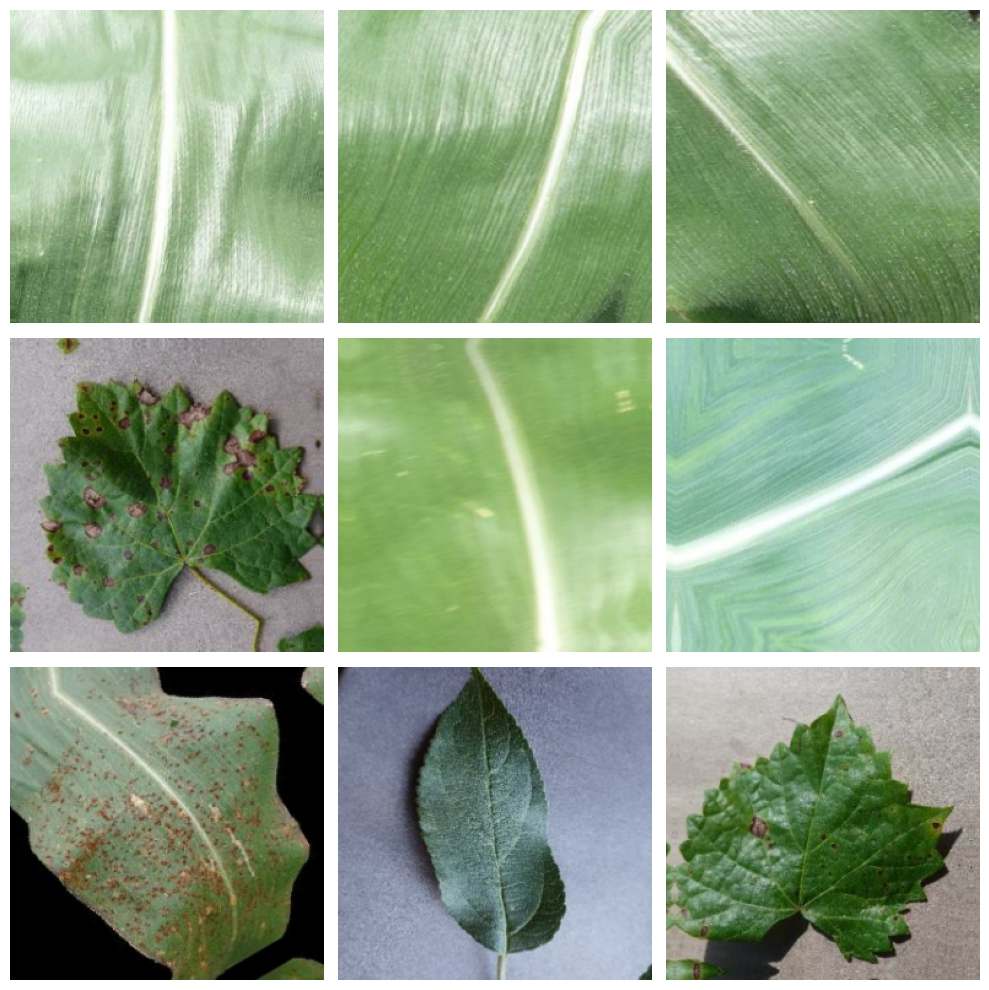

In [27]:
for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images)

    plt.figure(figsize=(10, 10))

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:


model = models.Sequential([
    layers.Input(shape=(256, 256, 3)),

    # Data Augmentation
    data_augmentation,

    # CNN Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # CNN Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # CNN Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Reduce features
    layers.GlobalAveragePooling2D(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # 10 Classes
    layers.Dense(10, activation="softmax")
])

In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

In [30]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [32]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/20


c:\Users\Dell\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


197/197 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - accuracy: 0.7506 - loss: 0.7793 - val_accuracy: 0.1962 - val_loss: 2.6992 - learning_rate: 0.0010
Epoch 2/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.8564 - loss: 0.4334 - val_accuracy: 0.3797 - val_loss: 2.7937 - learning_rate: 0.0010
Epoch 3/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.8894 - loss: 0.3321 - val_accuracy: 0.6543 - val_loss: 1.1670 - learning_rate: 0.0010
Epoch 4/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 413s 2s/step - accuracy: 0.9110 - loss: 0.2799 - val_accuracy: 0.6299 - val_loss: 1.8749 - learning_rate: 0.0010
Epoch 5/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 410s 2s/step - accuracy: 0.9267 - loss: 0.2283 - val_accuracy: 0.7395 - val_loss: 0.9798 - learning_rate: 0.0010
Epoch 6/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 411s 2s/step - accuracy: 0.9365 - loss: 0.1941 - val_accuracy: 0.7313 - val_loss: 0.9381 - learning_rate: 0.0010
Epoch 7/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 411s 2s/step - accuracy: 0.9416 - loss: 0.1770 - val_

In [33]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

43/43 ━━━━━━━━━━━━━━━━━━━━ 17s 398ms/step - accuracy: 0.9556 - loss: 0.1414
Test Accuracy: 95.56%
Test Loss: 0.1414


In [34]:
model.save("plant_disease_cnn.keras")

In [ ]:

print(os.getcwd())

c:\Users\Dell\Documents\intern\plant_disease_detection\Plant_Prediction


In [36]:
print(os.path.abspath("plant_disease_cnn.keras"))
print(os.path.exists("plant_disease_cnn.keras"))

c:\Users\Dell\Documents\intern\plant_disease_detection\Plant_Prediction\plant_disease_cnn.keras
True


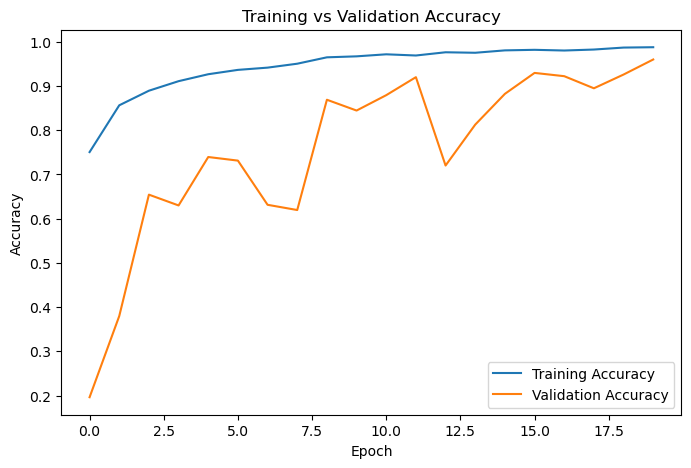

In [37]:
# Accuracy Graph

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [4]:
model = tf.keras.models.load_model(r"C:\Users\Dell\Documents\intern\plant_disease_detection\Plant_Prediction\plant_disease_cnn.keras")

In [5]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 334,944 (1.28 MB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 222,998 (871.09 KB)

In [14]:
dataset_path = r"C:\Users\Dell\Documents\intern\plant_disease_detection\Plant_Prediction\color"

In [15]:
selected_classes = [
    "Apple___Apple_scab",
    "Apple___Black_rot",
    "Apple___healthy",
    "Corn_(maize)___Common_rust_",
    "Corn_(maize)___healthy",
    "Grape___Black_rot",
    "Grape___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy"
]

In [16]:
data = []

for cls in selected_classes:
    class_path = os.path.join(dataset_path, cls)

    for file_name in os.listdir(class_path):
        image_path = os.path.join(class_path, file_name)
        data.append([image_path, cls])

df = pd.DataFrame(data, columns=["image_path", "label"])

print(df.shape)

(9005, 2)


In [17]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 6303
Validation: 1351
Test: 1351


In [18]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 32

In [19]:
class_to_index = {
    class_name: index
    for index, class_name in enumerate(selected_classes)
}

In [20]:
def preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [21]:
def create_dataset(dataframe, shuffle=False):

    image_paths = dataframe["image_path"].values
    labels = dataframe["label"].map(class_to_index).values

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )

    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=42
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [22]:
test_ds = create_dataset(test_df)

In [23]:
print(test_ds)
print("Test images:", len(test_df))

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
Test images: 1351


In [ ]:

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:


cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=selected_classes
)

fig, ax = plt.subplots(figsize=(14, 12))

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)

plt.title("Confusion Matrix")
plt.show()

In [ ]:

print(
    classification_report(
        y_true,
        y_pred,
        target_names=selected_classes,
        digits=4
    )
)

                             precision    recall  f1-score   support

         Apple___Apple_scab     0.9300    0.9789    0.9538        95
          Apple___Black_rot     0.9688    1.0000    0.9841        93
            Apple___healthy     0.8602    0.9756    0.9143       246
Corn_(maize)___Common_rust_     1.0000    0.9944    0.9972       179
     Corn_(maize)___healthy     0.9943    1.0000    0.9972       175
          Grape___Black_rot     1.0000    0.9605    0.9798       177
            Grape___healthy     1.0000    0.9683    0.9839        63
      Potato___Early_blight     0.9735    0.9800    0.9767       150
       Potato___Late_blight     0.9912    0.7533    0.8561       150
           Potato___healthy     0.8077    0.9130    0.8571        23

                   accuracy                         0.9556      1351
                  macro avg     0.9526    0.9524    0.9500      1351
               weighted avg     0.9595    0.9556    0.9549      1351



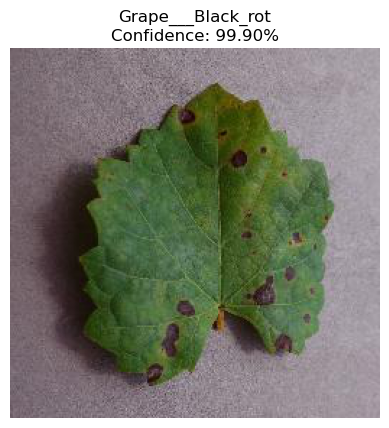

Prediction: Grape___Black_rot
Confidence: 99.90%


In [ ]:

image_path = r"C:\Users\Dell\Documents\intern\plant_disease_detection\Plant_Prediction\original.jpg"

img = tf.keras.utils.load_img(
    image_path,
    target_size=(256, 256)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)

predicted_index = np.argmax(prediction[0])
predicted_class = selected_classes[predicted_index]
confidence = np.max(prediction[0]) * 100

plt.imshow(img)
plt.axis("off")
plt.title(f"{predicted_class}\nConfidence: {confidence:.2f}%")
plt.show()

print("Prediction:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

In [52]:
model = tf.keras.models.load_model(
    r"C:\Users\Dell\Documents\intern\plant_disease_detection\Plant_Prediction\plant_disease_cnn.keras"
)

print("Model loaded successfully")

Model loaded successfully


In [53]:
external_test_path = r"C:\Users\Dell\Documents\intern\plant_disease_detection\Plant_Prediction\test images"
print(os.path.exists(external_test_path))

True


In [54]:
selected_classes = [
    "Apple___Apple_scab",
    "Apple___Black_rot",
    "Apple___healthy",
    "Corn_(maize)___Common_rust_",
    "Corn_(maize)___healthy",
    "Grape___Black_rot",
    "Grape___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy"
]

In [55]:
external_test_ds = tf.keras.utils.image_dataset_from_directory(
    external_test_path,
    class_names=selected_classes,
    image_size=(256, 256),
    batch_size=32,
    shuffle=False
)

Found 200 files belonging to 10 classes.


In [56]:
external_test_ds = external_test_ds.map(
    lambda images, labels: (
        tf.cast(images, tf.float32) / 255.0,
        labels
    )
)

In [57]:
external_loss, external_accuracy = model.evaluate(
    external_test_ds
)

print(f"External Test Accuracy: {external_accuracy * 100:.2f}%")
print(f"External Test Loss: {external_loss:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 402ms/step - accuracy: 0.9600 - loss: 0.1284
External Test Accuracy: 96.00%
External Test Loss: 0.1284


In [ ]:

y_true = []
y_pred = []

for images, labels in external_test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=selected_classes,
    digits=4
))

                             precision    recall  f1-score   support

         Apple___Apple_scab     0.9524    1.0000    0.9756        20
          Apple___Black_rot     0.9524    1.0000    0.9756        20
            Apple___healthy     0.9524    1.0000    0.9756        20
Corn_(maize)___Common_rust_     1.0000    1.0000    1.0000        20
     Corn_(maize)___healthy     1.0000    1.0000    1.0000        20
          Grape___Black_rot     1.0000    0.9500    0.9744        20
            Grape___healthy     1.0000    0.9500    0.9744        20
      Potato___Early_blight     0.8696    1.0000    0.9302        20
       Potato___Late_blight     1.0000    0.7000    0.8235        20
           Potato___healthy     0.9091    1.0000    0.9524        20

                   accuracy                         0.9600       200
                  macro avg     0.9636    0.9600    0.9582       200
               weighted avg     0.9636    0.9600    0.9582       200



In [ ]:

hashes = defaultdict(list)

for root, dirs, files in os.walk(external_test_path):
    for file in files:
        file_path = os.path.join(root, file)

        try:
            with open(file_path, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            hashes[file_hash].append(file_path)

        except Exception as e:
            print("Error:", file_path, e)

duplicate_groups = {
    h: paths
    for h, paths in hashes.items()
    if len(paths) > 1
}

print("Total images:", sum(len(v) for v in hashes.values()))
print("Unique images:", len(hashes))
print("Duplicate groups:", len(duplicate_groups))

Total images: 200
Unique images: 200
Duplicate groups: 0


In [ ]:

image_hashes = []

for root, dirs, files in os.walk(external_test_path):
    for file in files:
        file_path = os.path.join(root, file)

        try:
            with Image.open(file_path) as img:
                phash = imagehash.phash(img)

            image_hashes.append((file_path, phash))

        except Exception:
            pass

In [51]:
near_duplicates = []

for i in range(len(image_hashes)):
    for j in range(i + 1, len(image_hashes)):

        path1, hash1 = image_hashes[i]
        path2, hash2 = image_hashes[j]

        distance = hash1 - hash2

        if distance <= 4:
            near_duplicates.append(
                (path1, path2, distance)
            )

print("Near-duplicate pairs:", len(near_duplicates))

Near-duplicate pairs: 0


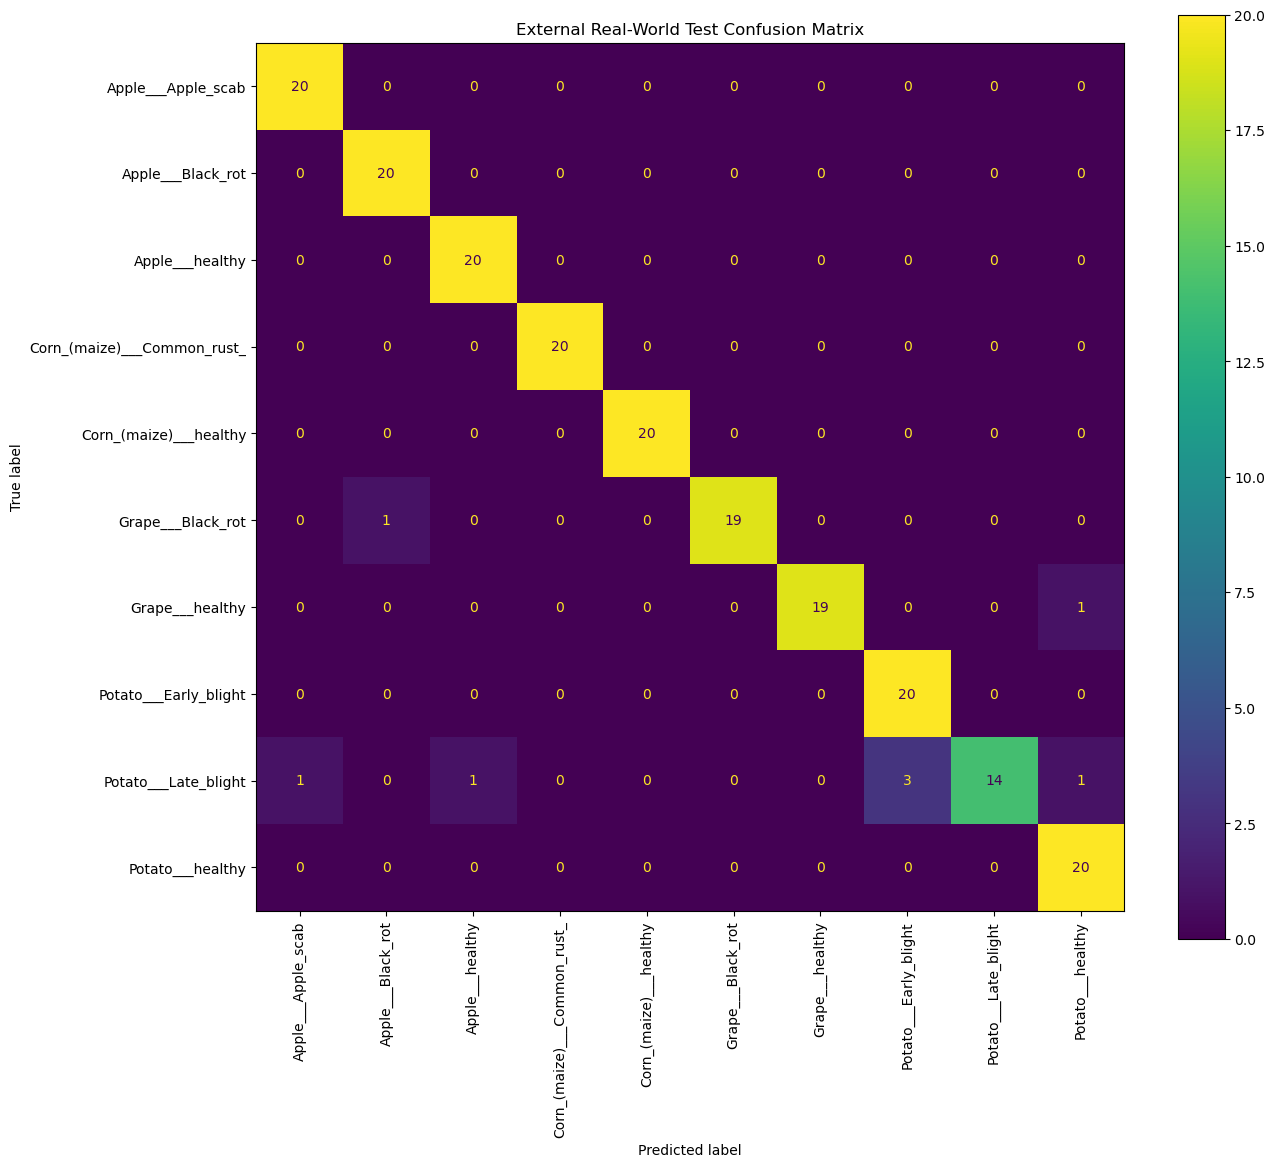

In [ ]:

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(14, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=selected_classes
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)

plt.title("External Real-World Test Confusion Matrix")
plt.show()